# Q1: Complete Text-to-Image Generation Pipeline
### Integrates: Text Preprocessing + CLIP Embedding + GAN-based Image Generation
**This is the full pipeline — Q4 + Q5 + Q6 combined into one system**

```
Raw Text → Preprocess → CLIP Embed → Conditional GAN → Generated Image
```

In [ ]:
# CELL 1: Install all dependencies
!pip install gradio torch torchvision transformers matplotlib numpy Pillow scikit-learn -q
print('All dependencies installed!')

All dependencies installed!


In [ ]:
# CELL 2: Imports & Global Config
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from transformers import CLIPTokenizer, CLIPTextModel
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr
import re
import os
import time
import random
import warnings
warnings.filterwarnings('ignore')

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE    = 64
LATENT_DIM  = 100
EMBED_DIM   = 512
PROJ_DIM    = 128
NUM_CLASSES = 3
BATCH_SIZE  = 64
EPOCHS      = 60
LR          = 0.0002
BETA1       = 0.5
MAX_TOKENS  = 77
CLIP_MODEL  = 'openai/clip-vit-base-patch32'

LABELS    = ['circle', 'square', 'triangle']
LABEL2IDX = {l: i for i, l in enumerate(LABELS)}

print(f'Device : {DEVICE}')
print(f'Config : IMG={IMG_SIZE}, LATENT={LATENT_DIM}, EMBED={EMBED_DIM}, PROJ={PROJ_DIM}')
print('Imports done!')

Device : cuda
Config : IMG=64, LATENT=100, EMBED=512, PROJ=128
Imports done!


In [ ]:
# CELL 3: Text Preprocessing Module (from Q5)

def preprocess_text(text: str) -> str:
    """Clean raw text before tokenization."""
    if not text or not text.strip():
        raise ValueError('Empty text input')
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s,.\'\-]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if len(text) > 200:
        text = text[:200].rsplit(' ', 1)[0]
    return text


def extract_shape_label(text: str) -> int:
    """
    Parse text to find which shape is being described.
    Maps free-form text to one of: circle, square, triangle
    """
    text_lower = text.lower()
    shape_keywords = {
        0: ['circle', 'round', 'circular', 'oval', 'sphere', 'disc', 'ball', 'curved'],
        1: ['square', 'box', 'cube', 'rectangle', 'rectangular', 'block', 'quadrilateral'],
        2: ['triangle', 'triangular', 'pyramid', 'cone', 'wedge', 'angular', 'pointed']
    }
    scores = {0: 0, 1: 0, 2: 0}
    for label_idx, keywords in shape_keywords.items():
        for kw in keywords:
            if kw in text_lower:
                scores[label_idx] += 1
    best = max(scores, key=scores.get)
    if scores[best] == 0:
        return 0
    return best



test_texts = [
    'a red circular disc with smooth edges',
    'a blue square box with sharp corners',
    'a green triangular pyramid shape'
]
print('Text Preprocessing + Shape Extraction Test:')
for t in test_texts:
    cleaned = preprocess_text(t)
    label   = extract_shape_label(t)
    print(f'  Input   : "{t}"')
    print(f'  Cleaned : "{cleaned}"')
    print(f'  Shape   : {LABELS[label]}')
    print()

Text Preprocessing + Shape Extraction Test:
  Input   : "a red circular disc with smooth edges"
  Cleaned : "a red circular disc with smooth edges"
  Shape   : circle

  Input   : "a blue square box with sharp corners"
  Cleaned : "a blue square box with sharp corners"
  Shape   : square

  Input   : "a green triangular pyramid shape"
  Cleaned : "a green triangular pyramid shape"
  Shape   : triangle



In [ ]:
# CELL 4: Load CLIP — Text Embedding Module (from Q5)
print('Loading CLIP tokenizer and text encoder...')

tokenizer    = CLIPTokenizer.from_pretrained(CLIP_MODEL)
text_encoder = CLIPTextModel.from_pretrained(CLIP_MODEL).to(DEVICE)
text_encoder.eval()

def get_text_embedding(text: str) -> np.ndarray:
    """Full embedding pipeline: raw text → 512D CLIP vector."""
    cleaned = preprocess_text(text)
    tokens  = tokenizer(
        cleaned,
        padding='max_length',
        max_length=MAX_TOKENS,
        truncation=True,
        return_tensors='pt'
    )
    tokens = {k: v.to(DEVICE) for k, v in tokens.items()}
    with torch.no_grad():
        output = text_encoder(**tokens)
    return output.pooler_output.squeeze(0).cpu().numpy()


test_emb = get_text_embedding('a smooth circular red shape')
print(f'CLIP loaded! Embedding shape: {test_emb.shape}')
print(f'Embedding norm: {np.linalg.norm(test_emb):.4f}')

Loading CLIP tokenizer and text encoder...


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.post_layernorm.bias                               | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.l

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP loaded! Embedding shape: (512,)
Embedding norm: 23.2005


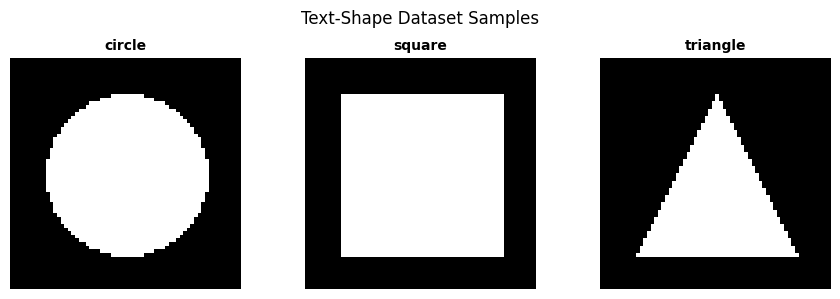

Dataset: 4000 samples with text descriptions


In [ ]:
# CELL 5: Synthetic Dataset with Text Descriptions


SHAPE_TEMPLATES = {
    0: [
        'a smooth circular shape with rounded edges',
        'a perfect circle with curved boundaries',
        'a round disc with uniform smooth edges',
        'a circular form with no corners or angles',
    ],
    1: [
        'a square shape with four equal sides',
        'a rectangular box with sharp right angles',
        'a geometric square with straight edges and corners',
        'a block shape with four sharp corners',
    ],
    2: [
        'a triangle with three pointed vertices',
        'a triangular pyramid with angular edges',
        'a three-sided shape pointing upward',
        'a wedge-shaped triangle with sharp tip',
    ]
}

class TextShapeDataset(Dataset):
    """
    Extended shape dataset with paired text descriptions.
    Each sample: (image_tensor, label_idx, text_description)
    """
    def __init__(self, num_samples=4000, img_size=64):
        self.num_samples = num_samples
        self.img_size    = img_size
        self.data        = [(i % NUM_CLASSES) for i in range(num_samples)]

    def _draw_shape(self, label_idx):
        img  = Image.new('L', (self.img_size, self.img_size), color=0)
        draw = ImageDraw.Draw(img)
        s, pad = self.img_size, self.img_size // 6
        if label_idx == 0:
            draw.ellipse([pad, pad, s-pad, s-pad], fill=255)
        elif label_idx == 1:
            draw.rectangle([pad, pad, s-pad, s-pad], fill=255)
        elif label_idx == 2:
            draw.polygon([(s//2, pad), (pad, s-pad), (s-pad, s-pad)], fill=255)
        arr = np.array(img, dtype=np.float32) / 127.5 - 1.0
        return torch.tensor(arr).unsqueeze(0)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        label = self.data[idx]
        image = self._draw_shape(label)
        text  = random.choice(SHAPE_TEMPLATES[label])
        return image, torch.tensor(label, dtype=torch.long), text


dataset = TextShapeDataset(num_samples=4000)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for i in range(3):
    img, label, text = dataset[i * (len(dataset)//3)]
    axes[i].imshow(img.squeeze().numpy(), cmap='gray')
    axes[i].set_title(f'{LABELS[label.item()]}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel(text, fontsize=7)
    axes[i].axis('off')
plt.suptitle('Text-Shape Dataset Samples', fontsize=12)
plt.tight_layout()
plt.show()
print(f'Dataset: {len(dataset)} samples with text descriptions')

In [ ]:
# CELL 6: Text-Conditioned GAN Architecture


class TextProjection(nn.Module):
    """
    Projects 512D CLIP embedding → PROJ_DIM (128D)
    This is the bridge between text encoder and GAN.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(EMBED_DIM, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Linear(256, PROJ_DIM),
            nn.LayerNorm(PROJ_DIM),
            nn.GELU()
        )
    def forward(self, x):
        return self.net(x)


class TextConditionedGenerator(nn.Module):
    """
    Generator conditioned on:
      - noise vector (LATENT_DIM)
      - projected CLIP text embedding (PROJ_DIM)
    Together: LATENT_DIM + PROJ_DIM → image
    """
    def __init__(self):
        super().__init__()
        self.text_proj = TextProjection()
        input_dim = LATENT_DIM + PROJ_DIM
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256 * 4 * 4),
            nn.BatchNorm1d(256 * 4 * 4),
            nn.ReLU(True)
        )
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),  nn.ReLU(True),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, noise, text_emb):
        proj = self.text_proj(text_emb)
        x    = torch.cat([noise, proj], dim=1)
        x    = self.fc(x)
        x    = x.view(-1, 256, 4, 4)
        return self.conv(x)


class TextConditionedDiscriminator(nn.Module):
    """
    Discriminator conditioned on projected CLIP embedding.
    Checks: does this image match this text description?
    """
    def __init__(self):
        super().__init__()
        self.text_proj = TextProjection()
        self.img_proj  = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1),  nn.LeakyReLU(0.2, True),
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64),  nn.LeakyReLU(0.2, True),
            nn.Conv2d(64, 128, 4, 2, 1),nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1),nn.BatchNorm2d(256),nn.LeakyReLU(0.2, True),
            nn.Flatten()
        )
        self.fc = nn.Sequential(
            nn.Linear(256 * 4 * 4 + PROJ_DIM, 512),
            nn.LeakyReLU(0.2, True),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, images, text_emb):
        img_feat  = self.img_proj(images)
        text_feat = self.text_proj(text_emb)
        combined  = torch.cat([img_feat, text_feat], dim=1)
        return self.fc(combined)


G = TextConditionedGenerator().to(DEVICE)
D = TextConditionedDiscriminator().to(DEVICE)

opt_G     = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, 0.999))
opt_D     = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, 0.999))
criterion = nn.BCELoss()

print(f'Generator params     : {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params : {sum(p.numel() for p in D.parameters()):,}')
print('Architecture ready!')

Generator params     : 1,800,481
Discriminator params : 3,018,721
Architecture ready!


In [ ]:
# CELL 7: Pre-compute Text Embeddings for Training


print('Pre-computing CLIP embeddings for all shape templates...')

TEMPLATE_EMBEDDINGS = {}
for label_idx, texts in SHAPE_TEMPLATES.items():
    embeds = []
    for t in texts:
        emb = get_text_embedding(t)
        embeds.append(emb)
    TEMPLATE_EMBEDDINGS[label_idx] = np.array(embeds)
    print(f'  {LABELS[label_idx]}: {len(embeds)} embeddings computed')

def get_batch_embeddings(labels_tensor):
    """For a batch of label indices, return matching CLIP embeddings as tensor."""
    batch_embs = []
    for lbl in labels_tensor.cpu().numpy():
        embs = TEMPLATE_EMBEDDINGS[lbl]
        chosen = embs[np.random.randint(len(embs))]
        batch_embs.append(chosen)
    return torch.tensor(np.array(batch_embs), dtype=torch.float32).to(DEVICE)

print('All embeddings pre-computed!')

Pre-computing CLIP embeddings for all shape templates...
  circle: 4 embeddings computed
  square: 4 embeddings computed
  triangle: 4 embeddings computed
All embeddings pre-computed!


Training for 60 epochs on cuda...
Expected: ~8-12 min on T4 GPU
Epoch [10/60]  G_loss: 9.1350  D_loss: 0.0001


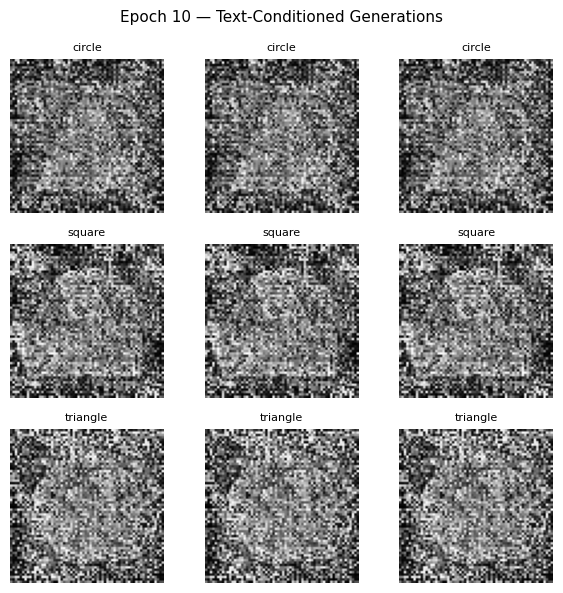

Epoch [20/60]  G_loss: 10.7149  D_loss: 0.0000


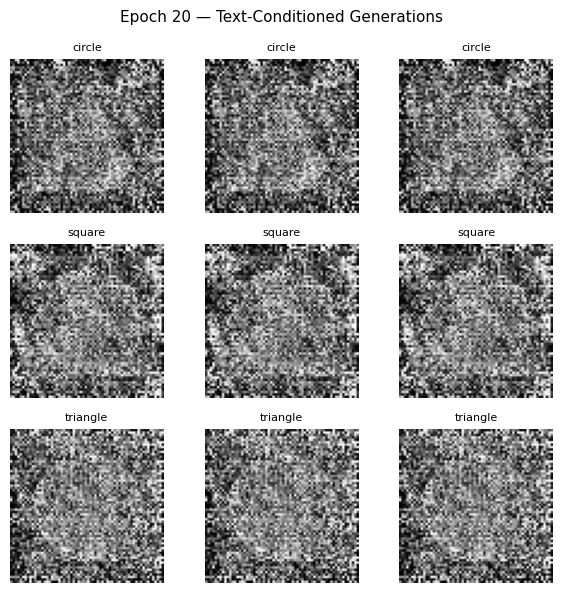

Epoch [30/60]  G_loss: 11.5598  D_loss: 0.0000


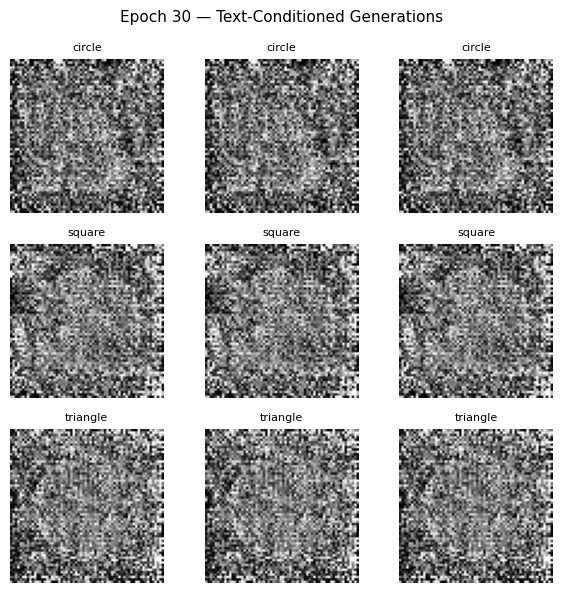

Epoch [40/60]  G_loss: 12.0517  D_loss: 0.0000


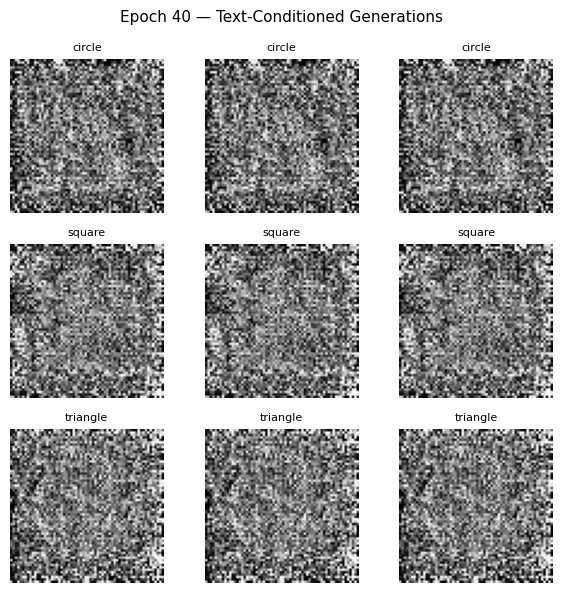

Epoch [50/60]  G_loss: 12.7266  D_loss: 0.0000


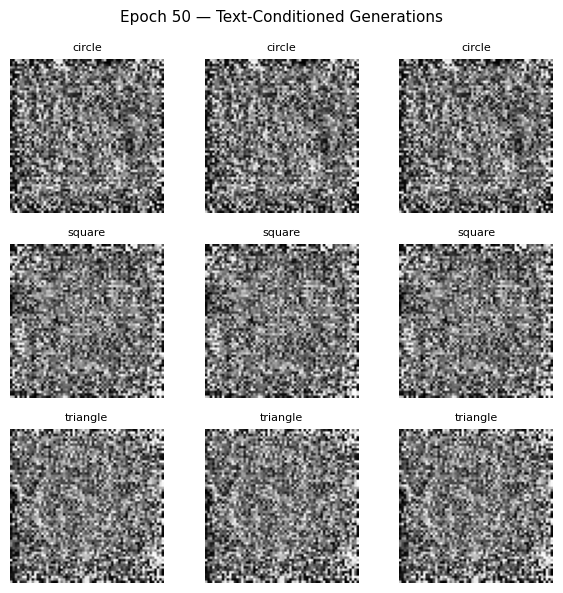

Epoch [60/60]  G_loss: 13.4425  D_loss: 0.0000


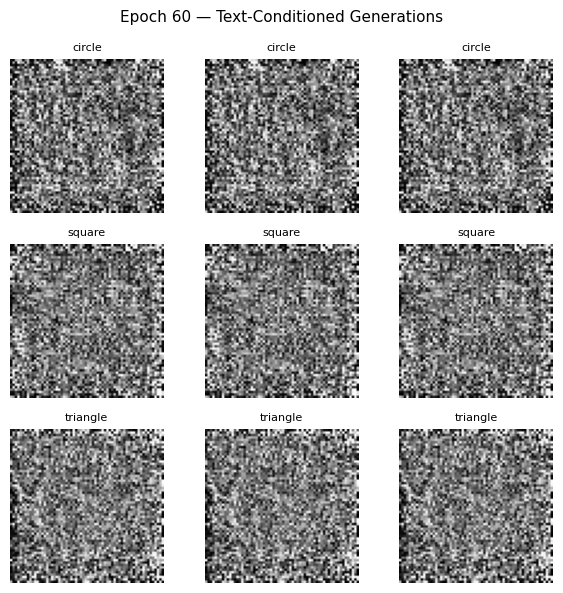

Training Complete!


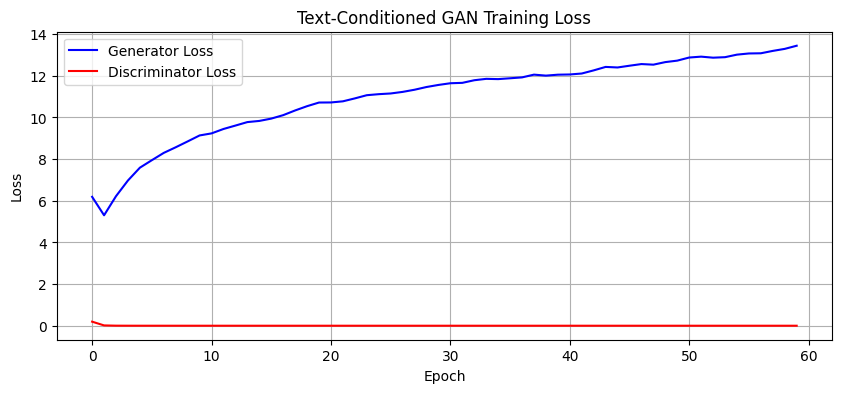

In [ ]:
# CELL 8: Training Loop — Text-Conditioned GAN
G_losses = []
D_losses = []


fixed_noise  = torch.randn(9, LATENT_DIM).to(DEVICE)
fixed_labels = torch.tensor([0,0,0,1,1,1,2,2,2])
fixed_embs   = get_batch_embeddings(fixed_labels)

print(f'Training for {EPOCHS} epochs on {DEVICE}...')
print('Expected: ~8-12 min on T4 GPU')
print('='*60)

for epoch in range(EPOCHS):
    epoch_g, epoch_d = 0, 0

    for real_imgs, labels, texts in loader:
        real_imgs = real_imgs.to(DEVICE)
        labels    = labels.to(DEVICE)
        B         = real_imgs.size(0)

        text_embs = get_batch_embeddings(labels)
        real_t    = torch.ones(B, 1).to(DEVICE)
        fake_t    = torch.zeros(B, 1).to(DEVICE)


        opt_D.zero_grad()
        out_real  = D(real_imgs, text_embs)
        loss_real = criterion(out_real, real_t)
        noise     = torch.randn(B, LATENT_DIM).to(DEVICE)
        fake_imgs = G(noise, text_embs)
        out_fake  = D(fake_imgs.detach(), text_embs)
        loss_fake = criterion(out_fake, fake_t)
        loss_D    = (loss_real + loss_fake) / 2
        loss_D.backward()
        opt_D.step()


        opt_G.zero_grad()
        noise     = torch.randn(B, LATENT_DIM).to(DEVICE)
        fake_imgs = G(noise, text_embs)
        out       = D(fake_imgs, text_embs)
        loss_G    = criterion(out, real_t)
        loss_G.backward()
        opt_G.step()

        epoch_g += loss_G.item()
        epoch_d += loss_D.item()

    avg_g = epoch_g / len(loader)
    avg_d = epoch_d / len(loader)
    G_losses.append(avg_g)
    D_losses.append(avg_d)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{EPOCHS}]  G_loss: {avg_g:.4f}  D_loss: {avg_d:.4f}')
        G.eval()
        with torch.no_grad():
            samples = G(fixed_noise, fixed_embs).cpu()
        G.train()
        fig, axes = plt.subplots(3, 3, figsize=(6, 6))
        for i in range(9):
            axes[i//3][i%3].imshow(samples[i].squeeze(), cmap='gray')
            axes[i//3][i%3].set_title(LABELS[fixed_labels[i].item()], fontsize=8)
            axes[i//3][i%3].axis('off')
        plt.suptitle(f'Epoch {epoch+1} — Text-Conditioned Generations', fontsize=11)
        plt.tight_layout()
        plt.show()

print('Training Complete!')

plt.figure(figsize=(10, 4))
plt.plot(G_losses, label='Generator Loss', color='blue')
plt.plot(D_losses, label='Discriminator Loss', color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Text-Conditioned GAN Training Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# CELL 9: Save Models
from google.colab import drive
drive.mount('/content/drive')

save_dir = '/content/drive/MyDrive/Q1_TextToImage'
os.makedirs(save_dir, exist_ok=True)
torch.save(G.state_dict(), f'{save_dir}/generator.pth')
torch.save(D.state_dict(), f'{save_dir}/discriminator.pth')
print(f'Saved to {save_dir}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to /content/drive/MyDrive/Q1_TextToImage


In [1]:
# CELL 10: Full Inference Pipeline

def full_pipeline(raw_text: str, num_samples: int = 4):
    """
    Complete text-to-image pipeline:
    Step 1 - Preprocess text
    Step 2 - CLIP embedding
    Step 3 - Extract shape label from text
    Step 4 - Generate image using GAN
    """

    cleaned   = preprocess_text(raw_text)


    embedding = get_text_embedding(cleaned)
    emb_tensor = torch.tensor(embedding, dtype=torch.float32)
    emb_batch  = emb_tensor.unsqueeze(0).repeat(num_samples, 1).to(DEVICE)

    label_idx  = extract_shape_label(raw_text)

    G.eval()
    with torch.no_grad():
        noise     = torch.randn(num_samples, LATENT_DIM).to(DEVICE)
        fake_imgs = G(noise, emb_batch).cpu()


    imgs_np   = ((fake_imgs.squeeze(1).numpy() + 1) / 2 * 255).astype(np.uint8)
    grid_size = int(np.ceil(np.sqrt(num_samples)))
    grid      = np.zeros((grid_size * IMG_SIZE, grid_size * IMG_SIZE), dtype=np.uint8)
    for i, img in enumerate(imgs_np):
        r, c = i // grid_size, i % grid_size
        grid[r*IMG_SIZE:(r+1)*IMG_SIZE, c*IMG_SIZE:(c+1)*IMG_SIZE] = img

    return grid, cleaned, embedding, label_idx



test_prompts = [
    'a smooth circular red disc',
    'a blue square box with sharp corners',
    'a green triangular pyramid'
]
print('Full pipeline test:')
for prompt in test_prompts:
    grid, cleaned, emb, lbl = full_pipeline(prompt, num_samples=4)
    plt.figure(figsize=(4, 4))
    plt.imshow(grid, cmap='gray')
    plt.title(f'Prompt: "{prompt}"\nDetected: {LABELS[lbl]}', fontsize=8)
    plt.axis('off')
    plt.show()
print('Pipeline working!')

Full pipeline test:


NameError: name 'preprocess_text' is not defined

In [ ]:
# CELL 11: Gradio UI — Complete Text-to-Image System
import gradio as gr

def gradio_pipeline(prompt: str, num_samples: int):
    if not prompt.strip():
        return None, '', '', 'Please enter a text description!'
    try:
        start = time.time()
        grid, cleaned, embedding, label_idx = full_pipeline(prompt, int(num_samples))
        elapsed = time.time() - start

        pil_img = Image.fromarray(grid)

        step_info = f"""PIPELINE STEPS:
{'='*45}
STEP 1 — Text Preprocessing:
  Input   : "{prompt}"
  Cleaned : "{cleaned}"

STEP 2 — CLIP Text Embedding:
  Model   : {CLIP_MODEL}
  Shape   : {embedding.shape} (512-dimensional vector)
  Norm    : {np.linalg.norm(embedding):.4f}
  Sample values: {embedding[:5].round(3).tolist()}

STEP 3 — Shape Detection from Text:
  Detected shape : {LABELS[label_idx]}

STEP 4 — GAN Image Generation:
  Noise vector  : {LATENT_DIM}D random vector
  Conditioning  : CLIP embedding projected to {PROJ_DIM}D
  Output size   : {IMG_SIZE}x{IMG_SIZE} per image
  Samples       : {num_samples}
  Time          : {elapsed:.2f}s
  Device        : {DEVICE}
"""
        emb_info = f"""EMBEDDING ANALYSIS:
{'='*45}
Dimensions : {len(embedding)}
Min value  : {embedding.min():.4f}
Max value  : {embedding.max():.4f}
Mean       : {embedding.mean():.4f}
Std        : {embedding.std():.4f}
Norm       : {np.linalg.norm(embedding):.4f}
"""
        return pil_img, step_info, emb_info, 'Generation complete!'
    except Exception as e:
        return None, '', '', f'Error: {str(e)}'


EXAMPLE_PROMPTS = [
    'a smooth circular disc with rounded edges',
    'a blue square box with sharp right angles',
    'a green triangular pyramid pointing upward',
    'a round ball shape with curved boundary',
    'a rectangular block with four corners',
]

with gr.Blocks(title='Text-to-Image Pipeline', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # Q1: Complete Text-to-Image Generation Pipeline
    ### Text Preprocessing → CLIP Embedding → GAN Generation
    Describe a shape in natural language and watch the full pipeline run!
    """)

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown('### Input')
            prompt_input = gr.Textbox(
                label='Text Description',
                placeholder='e.g. a smooth circular disc with rounded edges',
                value='a smooth circular disc with rounded edges',
                lines=3
            )
            num_samples = gr.Slider(1, 9, 4, step=1, label='Number of Images')
            generate_btn = gr.Button('Generate Image', variant='primary', size='lg')
            status_out   = gr.Textbox(label='Status', lines=1, interactive=False)

            gr.Markdown('### Example Prompts')
            for ex in EXAMPLE_PROMPTS:
                gr.Button(ex[:45]).click(lambda e=ex: e, outputs=prompt_input)

        with gr.Column(scale=2):
            output_image = gr.Image(label='Generated Image', type='pil', height=300)
            with gr.Tab('Pipeline Steps'):
                pipeline_info = gr.Textbox(label='Step-by-Step Info', lines=22, interactive=False)
            with gr.Tab('Embedding Analysis'):
                emb_info = gr.Textbox(label='Embedding Details', lines=12, interactive=False)

    generate_btn.click(
        fn=gradio_pipeline,
        inputs=[prompt_input, num_samples],
        outputs=[output_image, pipeline_info, emb_info, status_out]
    )

    gr.Markdown("""
    ---
    ### Pipeline Architecture:
    | Stage | Component | Output |
    |-------|-----------|--------|
    | 1 | Text Preprocessor | Cleaned text |
    | 2 | CLIP Text Encoder | 512D embedding |
    | 3 | Text Projection | 128D conditioning vector |
    | 4 | GAN Generator | 64x64 image |
    """)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://59521148d61eef046d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://59521148d61eef046d.gradio.live
